In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

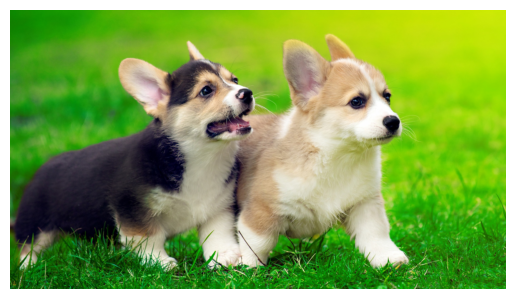

Image shape: (1080, 1920, 3)


In [2]:
path = 'images/dog.jpg'
image = cv2.imread(path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()
print(f'Image shape: {image.shape}')

In [5]:
resized_img = cv2.resize(image_rgb, (200, 200))
print(f'Resized image shape: {resized_img.shape}')

Resized image shape: (200, 200, 3)


In [6]:
pixel_values = resized_img.reshape((-1, 3))
print(f'Pixel values shape: {pixel_values.shape}')

Pixel values shape: (40000, 3)


In [8]:
pixel_values = np.float32(pixel_values)
print(f'Pixel values dtype: {pixel_values.dtype}')

Pixel values dtype: float32


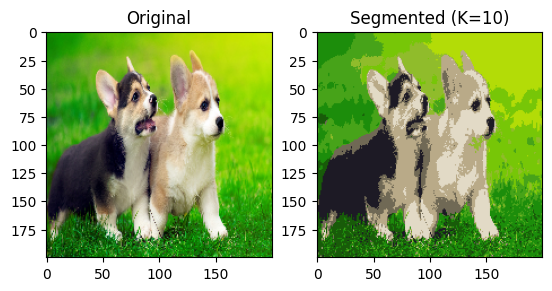

In [13]:
from model import KMeans


model = KMeans(k=10)
model.fit(pixel_values)


labels = model.predict(pixel_values)
segmented_image = model.centroids[labels].reshape(resized_img.shape).astype(np.uint8)


plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(resized_img)

plt.subplot(1, 2, 2)
plt.title(f"Segmented (K={model.k})")
plt.imshow(segmented_image)
plt.show()